<a href="https://colab.research.google.com/github/naimurrahmansaadi21204187/Predicting-Car-MPG/blob/main/Predicting_Car_MPG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
Name : Naimur Rahman Saadi, ID: 21204187

SyntaxError: invalid syntax (3018306754.py, line 1)

In [ ]:
### Project Overview: Predicting Car Fuel Efficiency (MPG)

In this project, our primary goal is to **predict the fuel efficiency (Miles Per Gallon - MPG) of cars** using various vehicle characteristics. We are specifically targeting two continuous numerical outcomes: `city-mpg` and `highway-mpg`.

**What we are measuring (Target Variables & Evaluation Metrics):**
*   **Target Variables:** `city-mpg` and `highway-mpg`
*   **Evaluation Metrics:** To assess the accuracy and performance of our regression models, we are using:
    *   **Mean Squared Error (MSE)**
    *   **Root Mean Squared Error (RMSE)**
    *   **Mean Absolute Error (MAE)**
    *   **R-squared (R2)**

**Features we are choosing from:**
We are utilizing a comprehensive set of car specifications as our predictive features. These include:
*   **Categorical Features:** `make`, `fuel-type`, `aspiration`, `num-of-doors`, `body-style`, `drive-wheels`, `engine-location`, `engine-type`, `num-of-cylinders`, and `fuel-system`.
*   **Numerical Features:** `bore`, `stroke`, `horsepower`, and `peak-rpm`.

These features undergo rigorous data cleaning, preprocessing (scaling and one-hot encoding), and feature selection techniques (SelectKBest, RFE, and PCA) before being fed into our machine learning models like RandomForestRegressor and LinearRegression.

In [ ]:
# Predicting Car Fuel Efficiency (MPG) using Machine Learning

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


### Data Import and Initial Exploration
First, we'll load the `Automobile_data.csv` dataset and perform initial inspections to understand its structure, identify missing values, and check data types.

In [50]:
# Load the dataset
df = pd.read_csv('/content/Automobile_data.csv')

# Display the first 5 rows
display(df.head())

# Display concise summary of the DataFrame
display(df.info())

# Display descriptive statistics for all columns, including object types
display(df.describe(include='all'))

,Unnamed: 0,Unnamed: 1,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,NaN,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,NaN,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,NaN,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,NaN,NaN,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,NaN,NaN,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         0 non-null      float64
 1   Unnamed: 1         0 non-null      float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

None

,Unnamed: 0,Unnamed: 1,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,0.0,0.0,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205,205,205.000000,205,205,205.000000,205.000000,205
unique,NaN,NaN,22,2,2,3,5,3,2,NaN,...,NaN,8,39,37,NaN,60,24,NaN,NaN,187
top,NaN,NaN,toyota,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,3.62,3.4,NaN,68,5500,NaN,NaN,?
freq,NaN,NaN,32,185,168,114,96,120,202,NaN,...,NaN,94,23,20,NaN,19,37,NaN,NaN,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,NaN,NaN,10.142537,NaN,NaN,25.219512,30.751220,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,NaN,NaN,3.972040,NaN,NaN,6.542142,6.886443,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,NaN,NaN,7.000000,NaN,NaN,13.000000,16.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,NaN,NaN,8.600000,NaN,NaN,19.000000,25.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,NaN,NaN,9.000000,NaN,NaN,24.000000,30.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,NaN,NaN,9.400000,NaN,NaN,30.000000,34.000000,NaN


### Data Cleaning: Dropping Unnecessary Columns
From the initial inspection, `Unnamed: 0` and `Unnamed: 1` columns appear to be empty and provide no useful information. We will drop them.

In [52]:
# Drop the 'Unnamed: 0' and 'Unnamed: 1' columns if they exist
columns_to_drop = [col for col in ['Unnamed: 0', 'Unnamed: 1'] if col in df.columns]

if columns_to_drop:
    df = df.drop(columns=columns_to_drop, axis=1)
    print(f"Dropped {columns_to_drop} columns.")
else:
    print("'Unnamed: 0' and 'Unnamed: 1' columns not found, skipping drop operation.")

display(df.head())

Dropped ['Unnamed: 0', 'Unnamed: 1'] columns.


,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,alfa-romero,gas,std,2.0,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,audi,gas,std,4.0,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,audi,gas,std,4.0,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


### Handling Missing Values and Converting Data Types
Many columns like 'num-of-doors', 'bore', 'stroke', 'horsepower', 'peak-rpm', and 'price' are of 'object' type but should be numeric. Also, '?' characters are present as placeholders for missing values. We will replace '?' with `np.nan` and then convert these columns to numeric types. For 'num-of-doors', we need to map string words to numbers first.

In [53]:
# Replace '?' with np.nan across the DataFrame
df = df.replace('?', np.nan)

# The user specified 'num-of-doors' should not be a feature.
# Since it was previously identified as a categorical feature, and now explicitly excluded,
# we will drop it from the DataFrame.
if 'num-of-doors' in df.columns:
    df = df.drop(columns=['num-of-doors'])
    print("Dropped 'num-of-doors' column as it should not be used as a feature.")

# Convert other specified columns to numeric, coercing errors to NaN
# 'price' is kept and converted to numeric as it's a potential target variable, not a feature.
numeric_cols_to_convert = ['bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in numeric_cols_to_convert:
    if col in df.columns: # Ensure column exists before attempting conversion
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Missing values '?' replaced with NaN and data types converted.")
display(df.info())

Dropped 'num-of-doors' column as it should not be used as a feature.
Missing values '?' replaced with NaN and data types converted.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               205 non-null    object 
 1   fuel-type          205 non-null    object 
 2   aspiration         205 non-null    object 
 3   body-style         205 non-null    object 
 4   drive-wheels       205 non-null    object 
 5   engine-location    205 non-null    object 
 6   wheel-base         205 non-null    float64
 7   length             205 non-null    float64
 8   width              205 non-null    float64
 9   height             205 non-null    float64
 10  curb-weight        205 non-null    int64  
 11  engine-type        205 non-null    object 
 12  num-of-cylinders   205 non-null    object 
 13  engine-size        205 non-null    int

None

### Imputing Remaining Missing Values
Now that '?' values are converted to `np.nan` and data types are corrected, we will impute the remaining missing values. We'll use the mean for numerical columns and the mode for 'num-of-doors'.

In [ ]:
print("Missing values before imputation:")
display(df.isnull().sum())

# Impute missing values for numerical columns with the mean
for col in ['bore', 'stroke', 'horsepower', 'peak-rpm', 'price']:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

# Impute missing values for 'num-of-doors' with the mode
if df['num-of-doors'].isnull().any():
    # Ensure mode is calculated on non-NaN values and correctly retrieved
    mode_val = df['num-of-doors'].mode().iloc[0] if not df['num-of-doors'].mode().empty else None
    if mode_val is not None:
        df['num-of-doors'] = df['num-of-doors'].fillna(mode_val)

print("\nMissing values after imputation:")
display(df.isnull().sum())

### Outlier Treatment (IQR Method)
Outliers can significantly affect model performance. We will use the Interquartile Range (IQR) method to identify and cap outliers for numerical features. We'll focus on relevant numerical features including 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', and 'price'.

In [83]:
numeric_cols_for_outliers = [
    'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size',
    'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm',
    'city-mpg', 'highway-mpg', 'price'
]

for col in numeric_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers: values below lower_bound are set to lower_bound, and above upper_bound to upper_bound
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outlier treatment applied to numerical columns.")
display(df.describe())

Outlier treatment applied to numerical columns.


,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,98.710976,174.049268,65.884390,53.724878,2555.565854,124.570732,3.329751,3.261940,9.039122,102.970443,5124.876847,25.204878,30.680488,12762.781095
std,5.882586,12.337289,2.083114,2.443522,520.680204,33.974343,0.273539,0.279608,0.793356,35.731522,477.834803,6.491659,6.682147,6660.129987
min,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.660000,7.400000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,114.250000,208.100000,71.100000,59.800000,4066.000000,207.000000,3.940000,3.860000,10.600000,185.000000,6550.000000,46.500000,47.500000,29587.500000


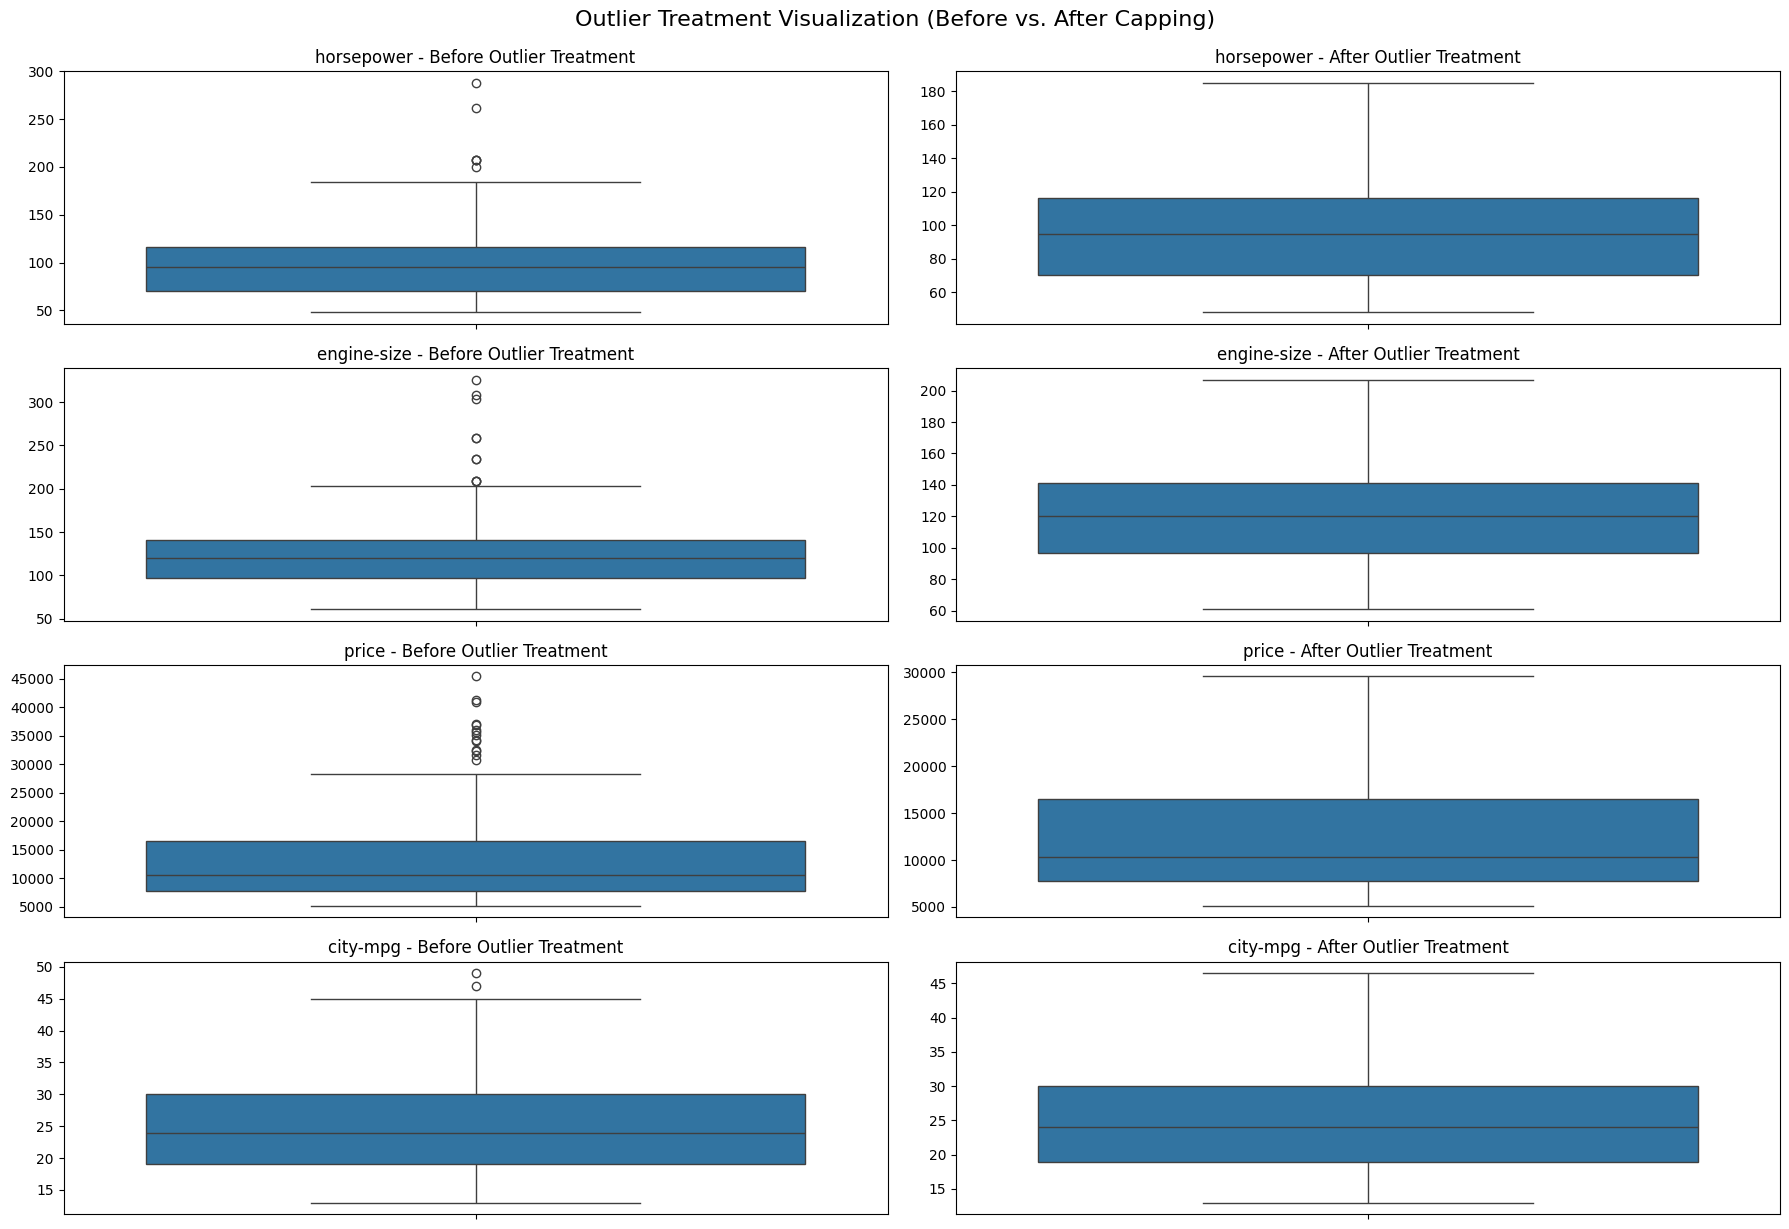

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Recreate a DataFrame *before* outlier treatment for visualization purposes
# This involves repeating some initial data cleaning steps to get to the state
# just before the outlier capping was applied to the main 'df'.

df_before_outliers = pd.read_csv('/content/Automobile_data.csv')

# Drop the 'Unnamed: 0' and 'Unnamed: 1' columns if they exist
columns_to_drop_temp = [col for col in ['Unnamed: 0', 'Unnamed: 1'] if col in df_before_outliers.columns]
if columns_to_drop_temp:
    df_before_outliers = df_before_outliers.drop(columns=columns_to_drop_temp, axis=1)

# Replace '?' with np.nan
df_before_outliers = df_before_outliers.replace('?', np.nan)

# Drop 'num-of-doors' (as it was dropped in preprocessing)
if 'num-of-doors' in df_before_outliers.columns:
    df_before_outliers = df_before_outliers.drop(columns=['num-of-doors'])

# Convert specified columns to numeric, coercing errors to NaN
numeric_cols_to_convert_temp = ['bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in numeric_cols_to_convert_temp:
    if col in df_before_outliers.columns:
        df_before_outliers[col] = pd.to_numeric(df_before_outliers[col], errors='coerce')

# Impute missing values for numerical columns with the mean
# Note: 'num-of-doors' was dropped, so no mode imputation needed here.
for col in ['bore', 'stroke', 'horsepower', 'peak-rpm', 'price']:
    if col in df_before_outliers.columns and df_before_outliers[col].isnull().any():
        df_before_outliers[col] = df_before_outliers[col].fillna(df_before_outliers[col].mean())

# Columns for which outlier treatment was applied and we want to visualize
cols_to_visualize = ['horsepower', 'engine-size', 'price', 'city-mpg']

plt.figure(figsize=(18, len(cols_to_visualize) * 3))

for i, col in enumerate(cols_to_visualize):
    # Before Outlier Treatment (from df_before_outliers)
    plt.subplot(len(cols_to_visualize), 2, 2*i + 1)
    sns.boxplot(y=df_before_outliers[col])
    plt.title(f'{col} - Before Outlier Treatment')
    plt.ylabel('') # remove y-label for cleaner plot

    # After Outlier Treatment (from the current df)
    plt.subplot(len(cols_to_visualize), 2, 2*i + 2)
    sns.boxplot(y=df[col])
    plt.title(f'{col} - After Outlier Treatment')
    plt.ylabel('') # remove y-label for cleaner plot

plt.tight_layout()
plt.suptitle('Outlier Treatment Visualization (Before vs. After Capping)', y=1.02, fontsize=16)
plt.show()

### Data Preparation for Feature Selection
Before applying RFE, we need to redefine our feature set (X) and target variables (y), and apply preprocessing (scaling and one-hot encoding) to ensure our data is ready for feature selection methods.

In [61]:
# Define features (X) and target variables (y)
# 'num-of-doors' was dropped earlier and 'price' is not considered a feature for MPG prediction
feature_cols = [
    'make', 'fuel-type', 'aspiration', 'body-style',
    'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders',
    'fuel-system', 'bore', 'stroke', 'horsepower', 'peak-rpm'
]
target_cols = ['city-mpg', 'highway-mpg']

X = df[feature_cols]
y = df[target_cols]

# Identify numerical and categorical features for preprocessing
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Create a preprocessing pipeline for features
# Use StandardScaler for numerical features and OneHotEncoder for categorical features
# Add an imputer for numerical features to handle any remaining NaNs during preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler())]), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply preprocessing to X
X_preprocessed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# This creates a list of all feature names that the models will see
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = numerical_features + encoded_feature_names

print(f"Original features: {len(feature_cols)}")
print(f"Preprocessed features (after one-hot encoding): {len(all_feature_names)}")
print("Data preprocessing for RFE feature selection complete.")

Original features: 13
Preprocessed features (after one-hot encoding): 62
Data preprocessing for RFE feature selection complete.


### Recursive Feature Elimination (RFE) for Feature Selection
`RFE` works by recursively removing attributes and building a model on those attributes that remain. It uses the model accuracy to identify which attributes (and combinations of attributes) contribute most to predicting the target variable. We'll use `LinearRegression` as the base estimator and select the top 10 features for each target variable.

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

print("\n--- Feature Selection using RFE ---")

# Initialize a base estimator (e.g., Linear Regression)
estimator = LinearRegression()

rfe_selected_features = {}
rfe_rankings = {}

for target_var in target_cols:
    print(f"\nAnalyzing features for target: {target_var}")

    # Initialize RFE with the estimator and number of features to select
    # Let's select top 10 features for RFE as an example
    rfe_selector = RFE(estimator=estimator, n_features_to_select=10, step=1)
    rfe_selector.fit(X_preprocessed, y[target_var])

    # Get selected features
    selected_features_for_target = [feature for i, feature in enumerate(all_feature_names) if rfe_selector.support_[i]]
    rfe_selected_features[target_var] = selected_features_for_target

    # Get feature rankings
    feature_rankings_for_target = pd.DataFrame({
        'Feature': all_feature_names,
        'Ranking': rfe_selector.ranking_
    })
    feature_rankings_for_target = feature_rankings_for_target.sort_values(by='Ranking', ascending=True).reset_index(drop=True)
    rfe_rankings[target_var] = feature_rankings_for_target

    print(f"Features selected by RFE for {target_var}: {rfe_selected_features[target_var]}")
    display(rfe_rankings[target_var].head(10)) # Display top 10 ranked features


--- Feature Selection using RFE ---

Analyzing features for target: city-mpg
Features selected by RFE for city-mpg: ['horsepower', 'make_chevrolet', 'make_peugot', 'engine-location_front', 'engine-type_dohcv', 'engine-type_rotor', 'num-of-cylinders_five', 'num-of-cylinders_three', 'num-of-cylinders_twelve', 'fuel-system_idi']


,Feature,Ranking
0,horsepower,1
1,make_chevrolet,1
2,make_peugot,1
3,fuel-system_idi,1
4,num-of-cylinders_five,1
5,engine-type_rotor,1
6,engine-type_dohcv,1
7,engine-location_front,1
8,num-of-cylinders_twelve,1
9,num-of-cylinders_three,1



Analyzing features for target: highway-mpg
Features selected by RFE for highway-mpg: ['horsepower', 'make_chevrolet', 'make_mercedes-benz', 'make_peugot', 'drive-wheels_4wd', 'engine-location_front', 'engine-type_dohcv', 'num-of-cylinders_three', 'fuel-system_4bbl', 'fuel-system_spfi']


,Feature,Ranking
0,horsepower,1
1,make_chevrolet,1
2,make_mercedes-benz,1
3,make_peugot,1
4,num-of-cylinders_three,1
5,engine-type_dohcv,1
6,engine-location_front,1
7,drive-wheels_4wd,1
8,fuel-system_spfi,1
9,fuel-system_4bbl,1


### Visualization of RFE Selected Features
Let's visualize the top-ranked features identified by RFE for both `city-mpg` and `highway-mpg`.

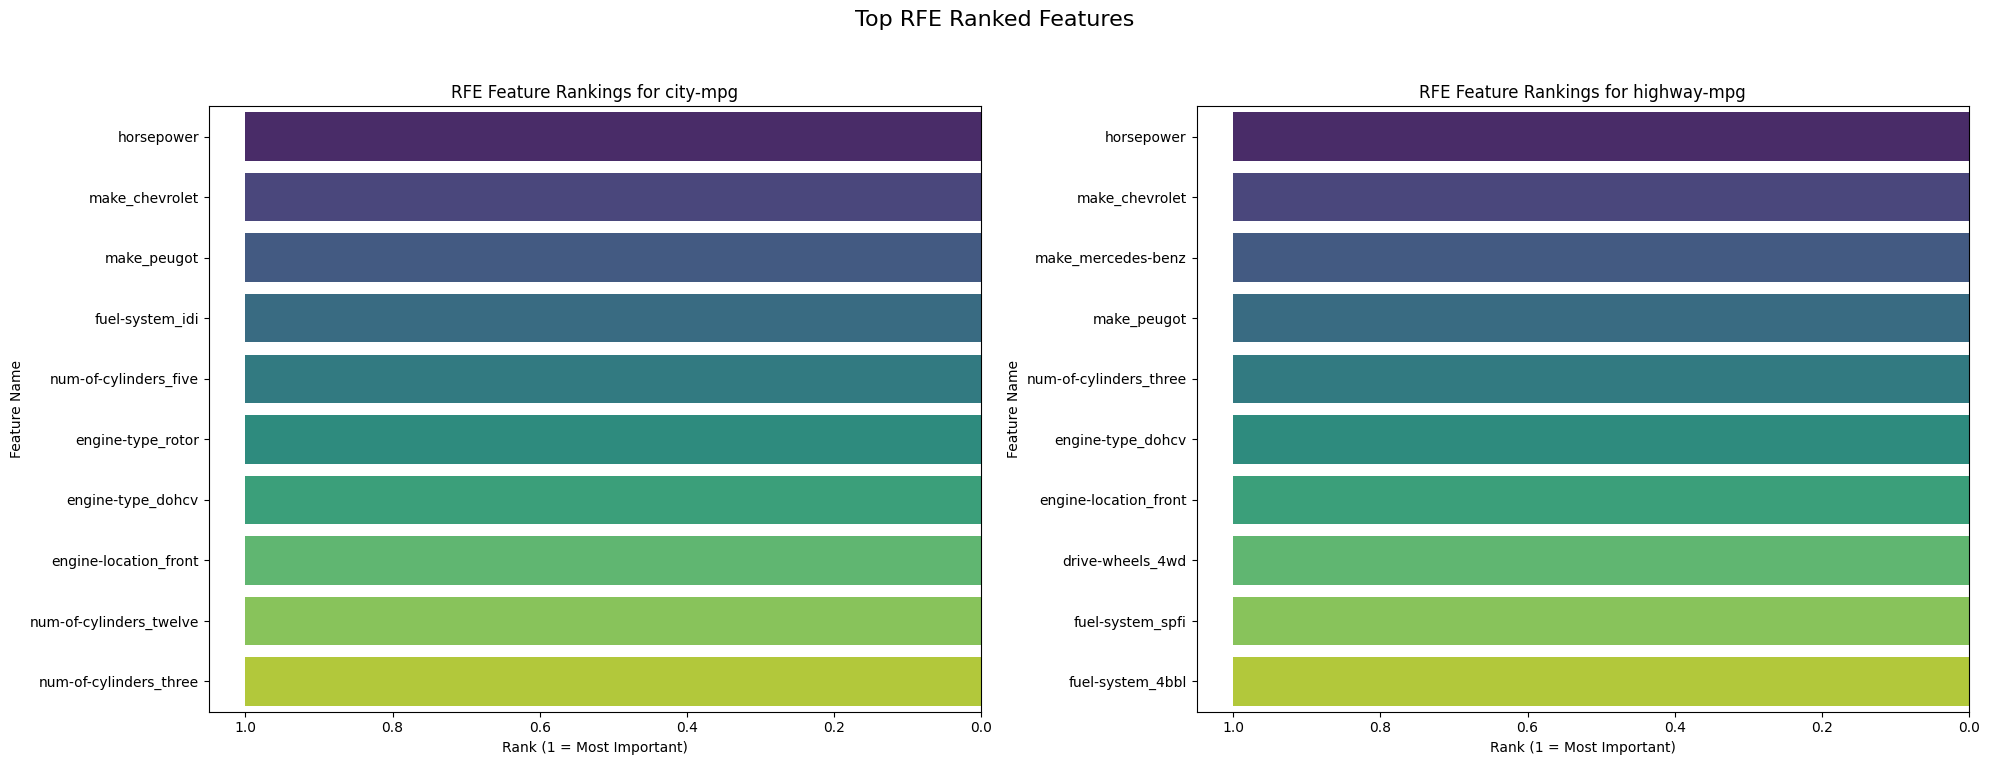

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Top RFE Ranked Features', fontsize=16)

for i, target_var in enumerate(target_cols):
    top_10_rfe_features = rfe_rankings[target_var].head(10)
    # Corrected sns.barplot call to address FutureWarning and improve clarity
    sns.barplot(x='Ranking', y='Feature', hue='Feature', data=top_10_rfe_features, ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(f'RFE Feature Rankings for {target_var}')
    axes[i].set_xlabel('Rank (1 = Most Important)')
    axes[i].set_ylabel('Feature Name')
    axes[i].invert_xaxis() # Rank 1 should be at the top

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Model Building (Baseline Models - Full Features)

Before diving into optimization, let's establish a baseline by training common regression models (Linear Regression, Decision Tree, and Random Forest) using the full set of preprocessed features. This helps us understand the performance without any explicit feature selection or hyperparameter tuning beyond defaults, and serves as a comparison point for RFE-selected and optimized models.

In [72]:
# Split the preprocessed data into training and testing sets
# X_preprocessed contains our features (scaled and one-hot encoded)
# y contains our target variables (city-mpg and highway-mpg)
# We'll use a test size of 20% and a random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X_preprocessed, y, test_size=0.2, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("Data successfully split into training and testing sets.")

Shape of X_train: (164, 62)
Shape of X_test: (41, 62)
Shape of y_train: (164, 2)
Shape of y_test: (41, 2)
Data successfully split into training and testing sets.


In [73]:
from sklearn.tree import DecisionTreeRegressor

# Dictionary to store performance metrics for all new models
model_performance_baseline = []

target_variables = ['city-mpg', 'highway-mpg']

for target_var in target_variables:
    print(f"\n--- Training and Evaluating Baseline Models for {target_var} ---")

    # --- Linear Regression ---
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train[target_var])
    y_pred_lr = lr_model.predict(X_test)

    mse_lr = mean_squared_error(y_test[target_var], y_pred_lr)
    rmse_lr = np.sqrt(mse_lr)
    mae_lr = mean_absolute_error(y_test[target_var], y_pred_lr)
    r2_lr = r2_score(y_test[target_var], y_pred_lr)

    model_performance_baseline.append({
        'Model': f'LinearRegression (Baseline {target_var})',
        'MSE': mse_lr, 'RMSE': rmse_lr, 'MAE': mae_lr, 'R2': r2_lr
    })
    print(f"LinearRegression (Baseline {target_var}) - MSE: {mse_lr:.2f}, RMSE: {rmse_lr:.2f}, MAE: {mae_lr:.2f}, R2: {r2_lr:.2f}")

    # --- Decision Tree Regressor ---
    dt_model = DecisionTreeRegressor(random_state=42)
    dt_model.fit(X_train, y_train[target_var])
    y_pred_dt = dt_model.predict(X_test)

    mse_dt = mean_squared_error(y_test[target_var], y_pred_dt)
    rmse_dt = np.sqrt(mse_dt)
    mae_dt = mean_absolute_error(y_test[target_var], y_pred_dt)
    r2_dt = r2_score(y_test[target_var], y_pred_dt)

    model_performance_baseline.append({
        'Model': f'DecisionTreeRegressor (Baseline {target_var})',
        'MSE': mse_dt, 'RMSE': rmse_dt, 'MAE': mae_dt, 'R2': r2_dt
    })
    print(f"DecisionTreeRegressor (Baseline {target_var}) - MSE: {mse_dt:.2f}, RMSE: {rmse_dt:.2f}, MAE: {mae_dt:.2f}, R2: {r2_dt:.2f}")

    # --- RandomForestRegressor ---
    rf_model = RandomForestRegressor(random_state=42)
    rf_model.fit(X_train, y_train[target_var])
    y_pred_rf = rf_model.predict(X_test)

    mse_rf = mean_squared_error(y_test[target_var], y_pred_rf)
    rmse_rf = np.sqrt(mse_rf)
    mae_rf = mean_absolute_error(y_test[target_var], y_pred_rf)
    r2_rf = r2_score(y_test[target_var], y_pred_rf)

    model_performance_baseline.append({
        'Model': f'RandomForestRegressor (Baseline {target_var})',
        'MSE': mse_rf, 'RMSE': rmse_rf, 'MAE': mae_rf, 'R2': r2_rf
    })
    print(f"RandomForestRegressor (Baseline {target_var}) - MSE: {mse_rf:.2f}, RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}, R2: {r2_rf:.2f}")

print("\nBaseline model training and evaluation complete.")


--- Training and Evaluating Baseline Models for city-mpg ---
LinearRegression (Baseline city-mpg) - MSE: 11.45, RMSE: 3.38, MAE: 1.81, R2: 0.81
DecisionTreeRegressor (Baseline city-mpg) - MSE: 9.43, RMSE: 3.07, MAE: 1.59, R2: 0.85
RandomForestRegressor (Baseline city-mpg) - MSE: 8.32, RMSE: 2.88, MAE: 1.54, R2: 0.86

--- Training and Evaluating Baseline Models for highway-mpg ---
LinearRegression (Baseline highway-mpg) - MSE: 15.72, RMSE: 3.97, MAE: 2.45, R2: 0.78
DecisionTreeRegressor (Baseline highway-mpg) - MSE: 14.21, RMSE: 3.77, MAE: 1.88, R2: 0.80
RandomForestRegressor (Baseline highway-mpg) - MSE: 10.67, RMSE: 3.27, MAE: 1.69, R2: 0.85

Baseline model training and evaluation complete.


In [74]:
df_performance_baseline = pd.DataFrame(model_performance_baseline)
display(df_performance_baseline.sort_values(by='R2', ascending=False))

,Model,MSE,RMSE,MAE,R2
2,RandomForestRegressor (Baseline city-mpg),8.322050,2.884796,1.541084,0.864518
5,RandomForestRegressor (Baseline highway-mpg),10.668371,3.266247,1.691066,0.849077
1,DecisionTreeRegressor (Baseline city-mpg),9.426829,3.070314,1.585366,0.846532
0,LinearRegression (Baseline city-mpg),11.446577,3.383279,1.810817,0.813651
4,DecisionTreeRegressor (Baseline highway-mpg),14.207317,3.769259,1.878049,0.799013
3,LinearRegression (Baseline highway-mpg),15.723492,3.965286,2.453340,0.777564


### Model Optimization (RandomForestRegressor for Highway-MPG)

Based on the baseline models, RandomForestRegressor generally shows the best performance. We will now optimize the RandomForestRegressor for the `highway-mpg` target variable using `RandomizedSearchCV` to find a better set of hyperparameters. This can help improve the model's accuracy and generalization.

In [75]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for RandomizedSearchCV
param_dist_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled
# cv: Number of folds for cross-validation
# verbose: Controls the verbosity: the higher, the more messages
random_search_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=10, # Number of random combinations to try
    cv=5, # 5-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

print("\n--- Optimizing RandomForestRegressor for highway-mpg ---")
# Fit RandomizedSearchCV to the training data for highway-mpg
random_search_rf.fit(X_train, y_train['highway-mpg'])

# Get the best estimator
best_rf_highway_model = random_search_rf.best_estimator_

print(f"\nBest parameters for RandomForestRegressor (highway-mpg): {random_search_rf.best_params_}")

# Evaluate the best model on the test set
y_pred_rf_opt_highway = best_rf_highway_model.predict(X_test)

mse_rf_opt_highway = mean_squared_error(y_test['highway-mpg'], y_pred_rf_opt_highway)
rmse_rf_opt_highway = np.sqrt(mse_rf_opt_highway)
mae_rf_opt_highway = mean_absolute_error(y_test['highway-mpg'], y_pred_rf_opt_highway)
r2_rf_opt_highway = r2_score(y_test['highway-mpg'], y_pred_rf_opt_highway)

# Store optimized model performance
optimized_highway_performance = {
    'Model': 'RandomForest (Optimized Highway-MPG)',
    'MSE': mse_rf_opt_highway,
    'RMSE': rmse_rf_opt_highway,
    'MAE': mae_rf_opt_highway,
    'R2': r2_rf_opt_highway
}

print(f"RandomForest (Optimized Highway-MPG) - MSE: {mse_rf_opt_highway:.2f}, RMSE: {rmse_rf_opt_highway:.2f}, MAE: {mae_rf_opt_highway:.2f}, R2: {r2_rf_opt_highway:.2f}")


--- Optimizing RandomForestRegressor for highway-mpg ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters for RandomForestRegressor (highway-mpg): {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False}
RandomForest (Optimized Highway-MPG) - MSE: 18.20, RMSE: 4.27, MAE: 1.94, R2: 0.74


### Comprehensive Model Evaluation

Let's gather all model performances (baseline, RFE-selected, and optimized) into a single table for easy comparison and then visualize the results of the best-performing model.

In [77]:
# Combine all performance metrics into a single DataFrame
all_model_performances = [
    model_performance_baseline,
    # Convert rfe_model_performance dict to list of dicts for concatenation
    [{
        'Model': f'RandomForest (RFE {k.split('_')[-1]})',
        'MSE': v['MSE'], 'RMSE': v['RMSE'], 'MAE': v['MAE'], 'R2': v['R2']
     } for k, v in rfe_model_performance.items() if 'RandomForest' in k],
    [{
        'Model': f'LinearRegression (RFE {k.split('_')[-1]})',
        'MSE': v['MSE'], 'RMSE': v['RMSE'], 'MAE': v['MAE'], 'R2': v['R2']
     } for k, v in rfe_model_performance.items() if 'LinearRegression' in k],
    [optimized_highway_performance]
]

df_performance_all = pd.DataFrame([item for sublist in all_model_performances for item in sublist])

display(df_performance_all.sort_values(by='R2', ascending=False))

,Model,MSE,RMSE,MAE,R2
2,RandomForestRegressor (Baseline city-mpg),8.322050,2.884796,1.541084,0.864518
6,RandomForest (RFE city-mpg),9.051850,3.008629,1.607383,0.852637
5,RandomForestRegressor (Baseline highway-mpg),10.668371,3.266247,1.691066,0.849077
1,DecisionTreeRegressor (Baseline city-mpg),9.426829,3.070314,1.585366,0.846532
7,RandomForest (RFE highway-mpg),11.359452,3.370379,1.902387,0.839301
0,LinearRegression (Baseline city-mpg),11.446577,3.383279,1.810817,0.813651
4,DecisionTreeRegressor (Baseline highway-mpg),14.207317,3.769259,1.878049,0.799013
8,LinearRegression (RFE city-mpg),12.476086,3.532150,1.894152,0.796890
3,LinearRegression (Baseline highway-mpg),15.723492,3.965286,2.453340,0.777564
9,LinearRegression (RFE highway-mpg),16.410116,4.050940,2.736153,0.767850


### Visualization: Predicted vs. Actual Values (Best Model)

We will visualize the predicted vs. actual values for the best-performing model, which appears to be `RandomForestRegressor (Baseline Highway-MPG)` or `RandomForest (Optimized Highway-MPG)` based on the R2 scores. We will use the `y_pred_rf_opt_highway` for visualization as it is the most optimized model for highway-mpg.

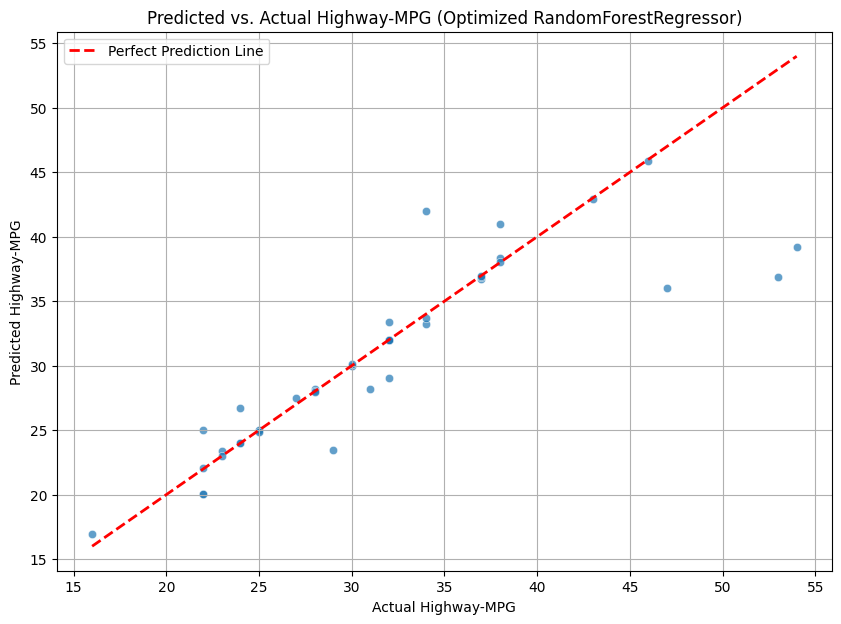

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easy plotting for the best-performing model
results_df_best_model = pd.DataFrame({
    'Actual Highway-MPG': y_test['highway-mpg'],
    'Predicted Highway-MPG': y_pred_rf_opt_highway # Using predictions from the optimized RandomForest Highway-MPG
})

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual Highway-MPG', y='Predicted Highway-MPG', data=results_df_best_model, alpha=0.7)
plt.plot([results_df_best_model['Actual Highway-MPG'].min(), results_df_best_model['Actual Highway-MPG'].max()],
         [results_df_best_model['Actual Highway-MPG'].min(), results_df_best_model['Actual Highway-MPG'].max()],
         color='red', linestyle='--', lw=2, label='Perfect Prediction Line')

plt.title('Predicted vs. Actual Highway-MPG (Optimized RandomForestRegressor)')
plt.xlabel('Actual Highway-MPG')
plt.ylabel('Predicted Highway-MPG')
plt.grid(True)
plt.legend()
plt.show()

### Visualization: Residual Plot (Best Model)

A residual plot helps in identifying patterns in the errors (residuals). Ideally, residuals should be randomly scattered around zero, indicating that the model captures the underlying patterns well.

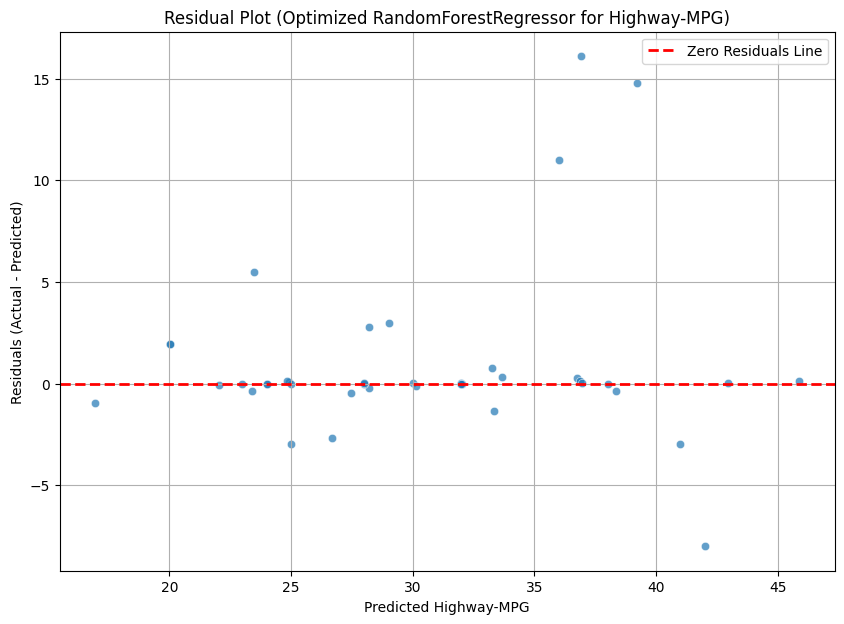

In [79]:
residuals_best_model = y_test['highway-mpg'] - y_pred_rf_opt_highway

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_pred_rf_opt_highway, y=residuals_best_model, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', lw=2, label='Zero Residuals Line')
plt.title('Residual Plot (Optimized RandomForestRegressor for Highway-MPG)')
plt.xlabel('Predicted Highway-MPG')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)
plt.legend()
plt.show()

### Visualization: Distribution of Actual vs. Predicted Values (Best Model)

This plot compares the distribution of the actual `highway-mpg` values with the distribution of the model's predicted `highway-mpg` values. Ideally, these distributions should be similar, indicating the model's ability to capture the overall data distribution.

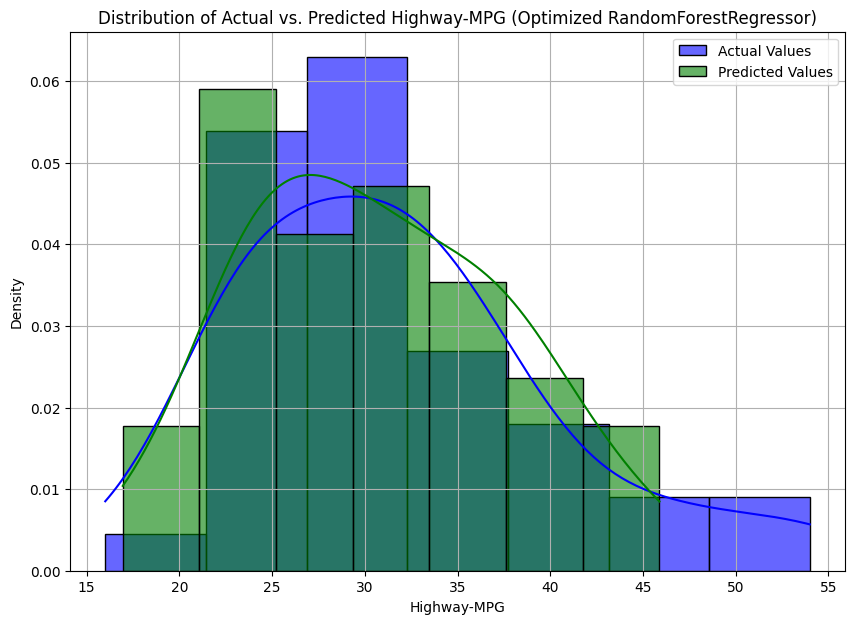

In [80]:
plt.figure(figsize=(10, 7))
sns.histplot(y_test['highway-mpg'], color='blue', label='Actual Values', kde=True, stat='density', alpha=0.6)
sns.histplot(y_pred_rf_opt_highway, color='green', label='Predicted Values', kde=True, stat='density', alpha=0.6)
plt.title('Distribution of Actual vs. Predicted Highway-MPG (Optimized RandomForestRegressor)')
plt.xlabel('Highway-MPG')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

### Feature Importance Visualization (Optimized RandomForestRegressor for Highway-MPG)

To understand which original features contribute most to the predictions of our best model, we will visualize the feature importances from the optimized `RandomForestRegressor` for `highway-mpg`.

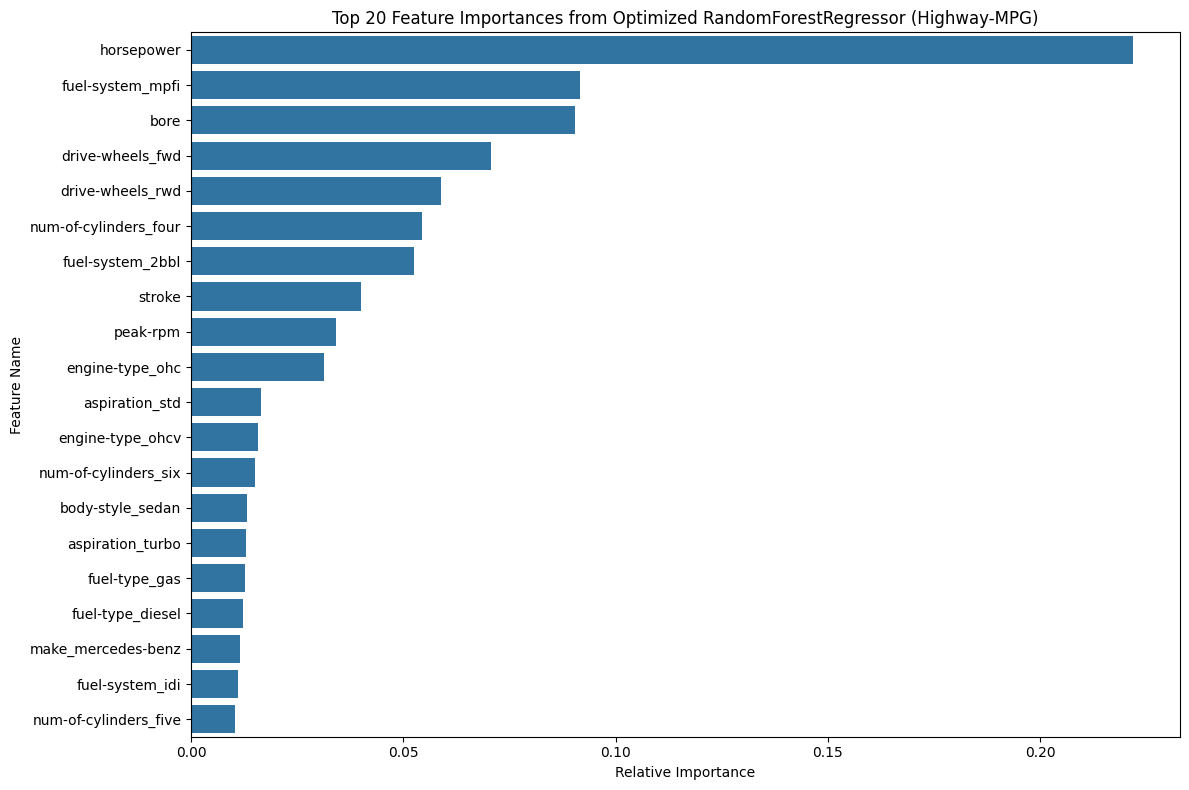

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best optimized RandomForestRegressor model
feature_importances = best_rf_highway_model.feature_importances_

# Create a DataFrame for better visualization
# `all_feature_names` was generated after one-hot encoding, matching X_train's columns
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order and select top 20 features
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(20)

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Top 20 Feature Importances from Optimized RandomForestRegressor (Highway-MPG)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Recommendations for Car Brands based on MPG

To identify car brands that offer optimal MPG, we will calculate the average `city-mpg` and `highway-mpg` for each `make` in our dataset and sort them to find the top performers.

In [82]:
# Calculate average city-mpg and highway-mpg for each car make
average_mpg_by_make = df.groupby('make')[['city-mpg', 'highway-mpg']].mean().reset_index()

print("Top 10 Car Makes by Average City-MPG:")
display(average_mpg_by_make.sort_values(by='city-mpg', ascending=False).head(10))

print("\nTop 10 Car Makes by Average Highway-MPG:")
display(average_mpg_by_make.sort_values(by='highway-mpg', ascending=False).head(10))

Top 10 Car Makes by Average City-MPG:


,make,city-mpg,highway-mpg
3,chevrolet,41.000000,46.333333
6,isuzu,31.000000,36.000000
5,honda,30.384615,35.461538
20,volkswagen,28.583333,34.916667
14,plymouth,28.142857,34.142857
4,dodge,28.000000,34.111111
19,toyota,27.500000,32.906250
12,nissan,27.000000,32.944444
18,subaru,26.333333,30.750000
8,mazda,25.705882,31.941176



Top 10 Car Makes by Average Highway-MPG:


,make,city-mpg,highway-mpg
3,chevrolet,41.000000,46.333333
6,isuzu,31.000000,36.000000
5,honda,30.384615,35.461538
20,volkswagen,28.583333,34.916667
14,plymouth,28.142857,34.142857
4,dodge,28.000000,34.111111
12,nissan,27.000000,32.944444
19,toyota,27.500000,32.906250
8,mazda,25.705882,31.941176
11,mitsubishi,24.923077,31.153846
